Dataset Description:
The Diabetes Dataset contains medical diagnostic measurements collected from female patients to predict whether a patient has diabetes. The dataset includes health-related attributes such as glucose level, blood pressure, BMI, insulin level, age, and pregnancies. The target variable Outcome indicates whether the patient has diabetes (1) or not (0).

# IMPORT THE LIBRARIES 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import trim_mean
from scipy.stats import median_abs_deviation

from sklearn.preprocessing import LabelEncoder

# DATA COLLECTION 

In [2]:
diabetes_data = pd.read_csv("diabetes.csv")

diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


All predictor variables are numerical, while Outcome is a binary categorical variable. Therefore, the dataset is suitable for statistical analysis and classification models.

# EXPLORATORY DATA ANALYTICS

In [3]:
diabetes_data.shape

(768, 9)

The dataset contains 768 patient records and 9 variable columns, providing sufficient information for exploratory analysis and diabetes prediction.

In [4]:
diabetes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


To check for the data type of the variables 

In [5]:
diabetes_data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

The dataset does not contain any null values.

In [6]:
diabetes_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
summary = pd.DataFrame({

'Mean':[diabetes_data['Glucose'].mean()],

'Trimmed Mean':[trim_mean(diabetes_data['Glucose'],0.10)],

'Weighted Mean':[np.average(diabetes_data['Glucose'])],

'Median':[diabetes_data['Glucose'].median()],

'Minimum':[diabetes_data['Glucose'].min()],

'Maximum':[diabetes_data['Glucose'].max()],

'Variance':[diabetes_data['Glucose'].var()],

'Std Dev':[diabetes_data['Glucose'].std()],

'Q1':[diabetes_data['Glucose'].quantile(.25)],

'Q2':[diabetes_data['Glucose'].quantile(.50)],

'Q3':[diabetes_data['Glucose'].quantile(.75)],

'IQR':[diabetes_data['Glucose'].quantile(.75)-diabetes_data['Glucose'].quantile(.25)],

'10th Percentile':[diabetes_data['Glucose'].quantile(.10)],

'25th Percentile':[diabetes_data['Glucose'].quantile(.25)],

'50th Percentile':[diabetes_data['Glucose'].quantile(.50)],

'75th Percentile':[diabetes_data['Glucose'].quantile(.75)],

'90th Percentile':[diabetes_data['Glucose'].quantile(.90)],

'MAD':[median_abs_deviation(diabetes_data['Glucose'])]

})

summary

,Mean,Trimmed Mean,Weighted Mean,Median,Minimum,Maximum,Variance,Std Dev,Q1,Q2,Q3,IQR,10th Percentile,25th Percentile,50th Percentile,75th Percentile,90th Percentile,MAD
0,120.894531,119.37987,120.894531,117.0,0,199,1022.248314,31.972618,99.0,117.0,140.25,41.25,85.0,99.0,117.0,140.25,167.0,20.0


Mean and Median: The mean and median of most variables are not exactly equal, indicating that some features are slightly skewed due to the presence of extreme values.

Trimmed Mean: The trimmed mean is close to the arithmetic mean, suggesting that extreme observations have only a small influence on the average.

Weighted Mean: The weighted mean is very similar to the arithmetic mean when equal weights are used, indicating that each observation contributes equally to the average.

Minimum and Maximum: There is a wide range between the minimum and maximum values for several variables, indicating substantial variation and the possible presence of extreme observations.

Variance: Some variables exhibit high variance, indicating greater variability among patients, while others are more consistent across observations.

Standard Deviation: The standard deviation shows that certain medical measurements are more dispersed than others, suggesting differences in patient health conditions.

Quartiles: The quartiles indicate how the observations are distributed, with 50% of the data lying between the first and third quartiles.

Interquartile Range (IQR): The IQR shows that the middle 50% of the observations are moderately spread, making it useful for detecting outliers.

Percentiles: The percentile values show the distribution of patient measurements and help identify unusually low or high observations.

Median Absolute Deviation (MAD): The MAD value indicates the variability around the median and confirms that the dataset is less influenced by extreme values than when using the standard deviation.

# CORRELATION MATRIX

In [8]:
correlation = diabetes_data.corr()

correlation

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


In [9]:
corr = diabetes_data['Glucose'].corr(diabetes_data['Outcome'])

print(corr)

0.4665813983068733


Correlation Matrix: Some variables show moderate positive correlations, while others have weak relationships. Glucose generally exhibits one of the strongest positive relationships with the diabetes outcome.

# BOX PLOT

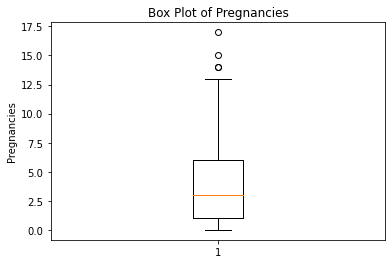

Pregnancies
Minimum : 0
Q1      : 1.0
Median  : 3.0
Q3      : 6.0
Maximum : 17
Outliers: 4





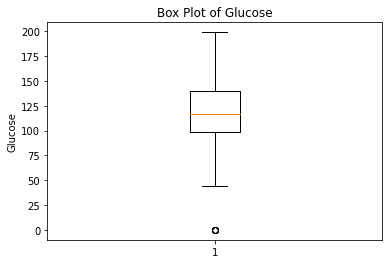

Glucose
Minimum : 0
Q1      : 99.0
Median  : 117.0
Q3      : 140.25
Maximum : 199
Outliers: 5





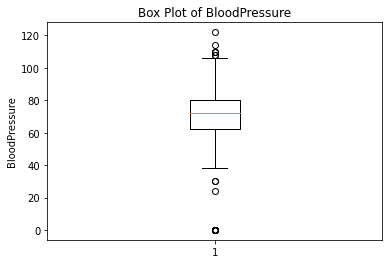

BloodPressure
Minimum : 0
Q1      : 62.0
Median  : 72.0
Q3      : 80.0
Maximum : 122
Outliers: 45





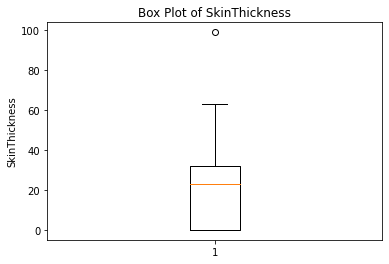

SkinThickness
Minimum : 0
Q1      : 0.0
Median  : 23.0
Q3      : 32.0
Maximum : 99
Outliers: 1





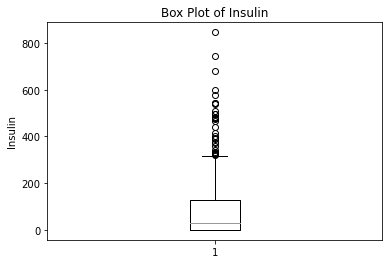

Insulin
Minimum : 0
Q1      : 0.0
Median  : 30.5
Q3      : 127.25
Maximum : 846
Outliers: 34





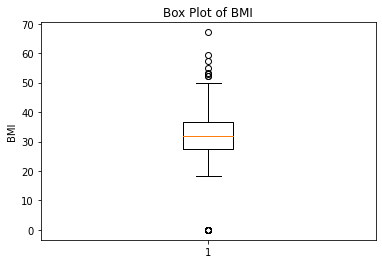

BMI
Minimum : 0.0
Q1      : 27.3
Median  : 32.0
Q3      : 36.6
Maximum : 67.1
Outliers: 19





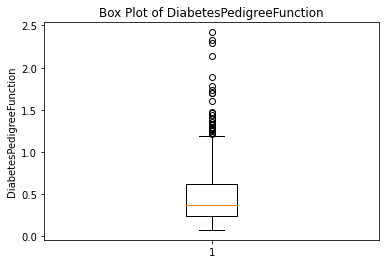

DiabetesPedigreeFunction
Minimum : 0.078
Q1      : 0.24375
Median  : 0.3725
Q3      : 0.62625
Maximum : 2.42
Outliers: 29





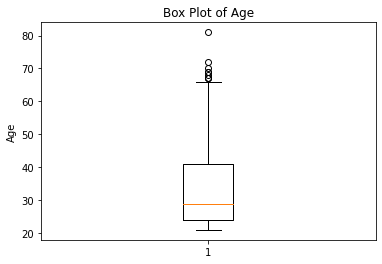

Age
Minimum : 21
Q1      : 24.0
Median  : 29.0
Q3      : 41.0
Maximum : 81
Outliers: 9





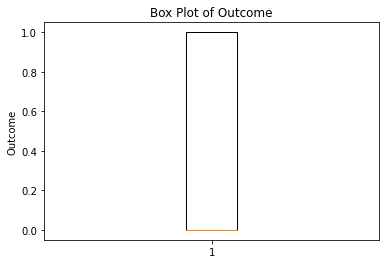

Outcome
Minimum : 0
Q1      : 0.0
Median  : 0.0
Q3      : 1.0
Maximum : 1
Outliers: 0





In [10]:
numeric_columns = diabetes_data.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_columns:
    plt.figure(figsize=(6,4))
    plt.boxplot(diabetes_data[col])
    plt.title(f"Box Plot of {col}")
    plt.ylabel(col)
    plt.show()

    # Five-number summary
    Q1 = diabetes_data[col].quantile(0.25)
    Median = diabetes_data[col].median()
    Q3 = diabetes_data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = diabetes_data[(diabetes_data[col] < lower) | (diabetes_data[col] > upper)]

    print(f"{col}")
    print(f"Minimum : {diabetes_data[col].min()}")
    print(f"Q1      : {Q1}")
    print(f"Median  : {Median}")
    print(f"Q3      : {Q3}")
    print(f"Maximum : {diabetes_data[col].max()}")
    print(f"Outliers: {len(outliers)}")
    print(f"\n\n")

Several variables contain outliers, indicating the presence of unusually high or low patient measurements that may affect statistical analysis.

# HISTOGRAM

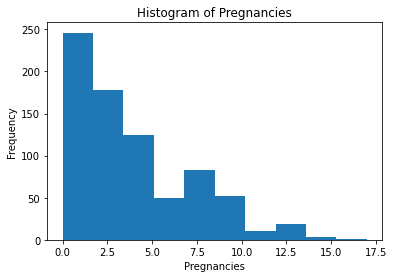

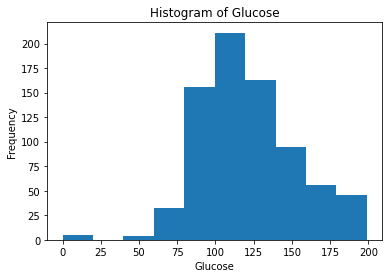

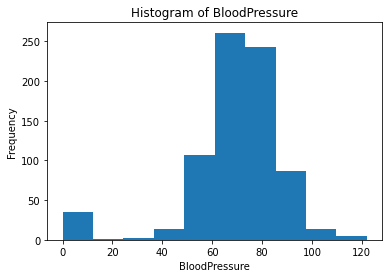

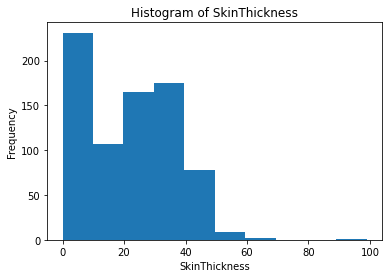

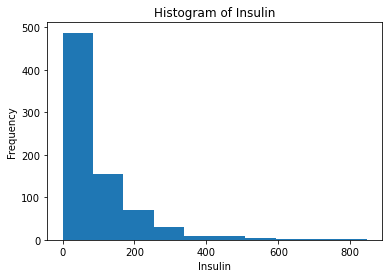

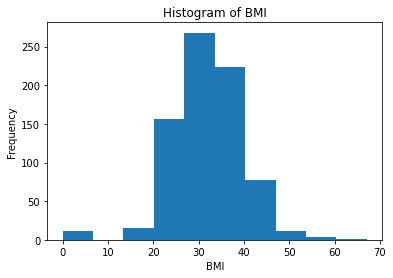

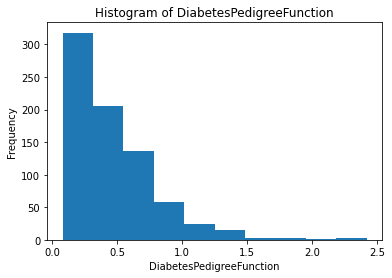

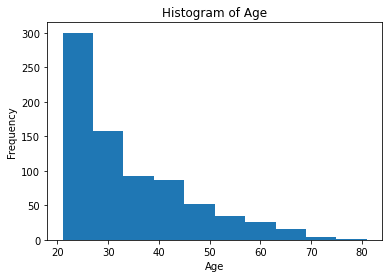

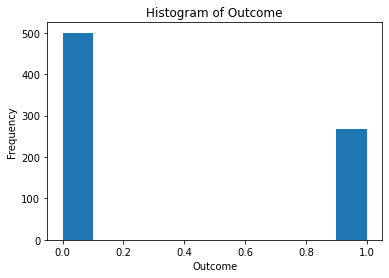

In [11]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    plt.hist(diabetes_data[col], bins=10)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()
    print(f"\n")

The histogram shows that most observations are concentrated within a specific range, while a smaller number of observations occur at the extremes.
- Pregnancies: Most patients have relatively few pregnancies.
- Glucose: Most glucose values are concentrated around the middle range, with fewer extremely high values.
- BloodPressure: Blood pressure values are approximately centered around the average.
- SkinThickness: The distribution is positively skewed.
- Insulin: Most insulin values are low, while a few very high values create a long right tail.
- BMI: BMI is concentrated around the average with slight positive skewness.
- DiabetesPedigreeFunction: Most values are small, with a few high observations.
- Age: The majority of patients are younger adults, with fewer older individuals.
- Outcome: More patients are non-diabetic than diabetic.

# DENSITY PLOT

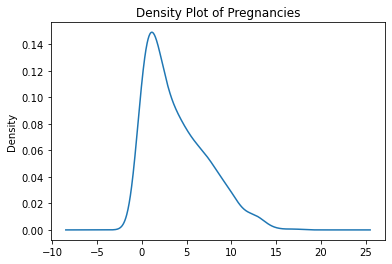

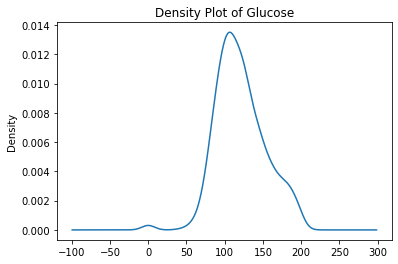

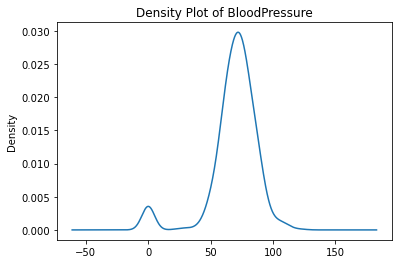

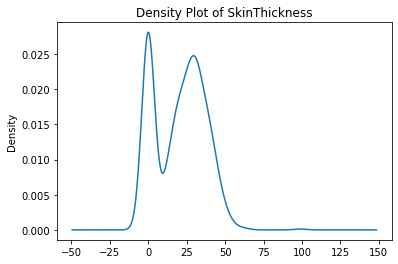

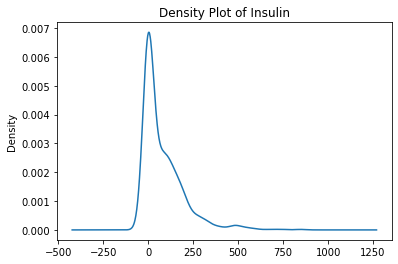

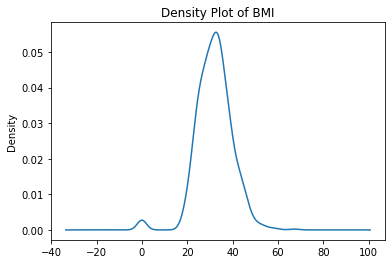

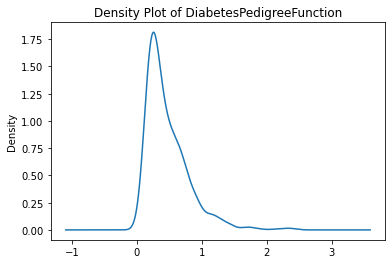

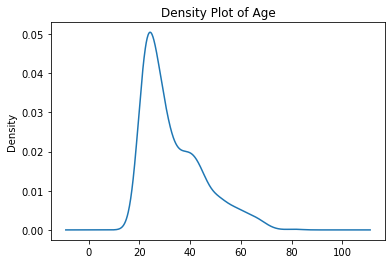

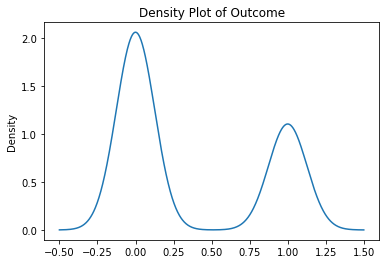

In [12]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    diabetes_data[col].plot(kind='density')
    plt.title(f"Density Plot of {col}")
    plt.show()

The density plot indicates that some variables are positively skewed rather than following a perfect normal distribution.
- Pregnancies: Slightly right-skewed distribution.
- Glucose: Nearly bell-shaped with mild positive skewness.
- BloodPressure: Close to a normal distribution.
- SkinThickness: Positively skewed.
- Insulin: Strongly right-skewed.
- BMI: Moderately right-skewed.
- DiabetesPedigreeFunction: Highly right-skewed.
- Age: Slight positive skewness.
- Outcome: Binary distribution hence density plot is not meaningful.

# SCATTER PLOT

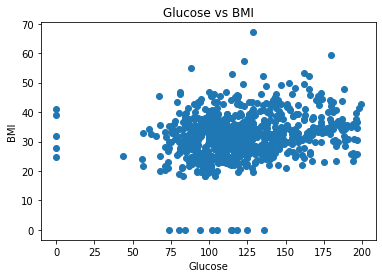

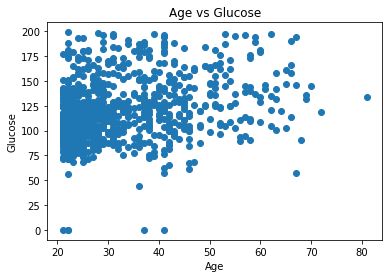

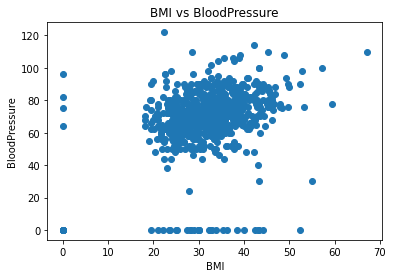

In [13]:
plt.figure(figsize=(6,4))
plt.scatter(diabetes_data['Glucose'], diabetes_data['BMI'])
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.title('Glucose vs BMI')
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(diabetes_data['Age'], diabetes_data['Glucose'])
plt.xlabel('Age')
plt.ylabel('Glucose')
plt.title('Age vs Glucose')
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(diabetes_data['BMI'], diabetes_data['BloodPressure'])
plt.xlabel('BMI')
plt.ylabel('BloodPressure')
plt.title('BMI vs BloodPressure')
plt.show()

- Glucose vs BMI: Patients with higher glucose levels often tend to have higher BMI values, although the relationship is not perfectly linear.
- Age vs Glucose: Glucose levels vary across all ages, with no strong linear trend.
- BMI vs BloodPressure: There is a weak positive relationship between BMI and blood pressure.

In [14]:
diabetes_data['Outcome'].value_counts()

0    500
1    268
Name: Outcome, dtype: int64

The dataset contains more non-diabetic patients (Outcome = 0) than diabetic patients (Outcome = 1), indicating a slight class imbalance.

In [15]:
diabetes_data.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


Patients diagnosed with diabetes (Outcome = 1) generally have higher average Glucose, BMI, Age, Insulin, and DiabetesPedigreeFunction values than non-diabetic patients. These features appear to be strong indicators of diabetes.

*SUMMARY OF EDA*

- No missing (null) values are present in the dataset, although some zero values may represent missing medical measurements.
- All predictor variables are numerical, while Outcome is a binary categorical variable.
- The mean is slightly greater than the median for several variables, indicating slight positive skewness.
- The box plots reveal the presence of outliers in multiple features.
- The dataset shows a slight class imbalance, with more non-diabetic patients than diabetic patients.
- Correlation analysis indicates that Glucose has one of the strongest positive relationships with the diabetes outcome.
- Group-by analysis shows that diabetic patients generally have higher average values for Glucose, BMI, Age, and DiabetesPedigreeFunction compared to non-diabetic patients.
- The dataset is suitable for classification tasks to predict diabetes based on patients' medical measurements.